In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls

drive  sample_data


In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
from scipy import stats
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier


sns.set(style="darkgrid", palette="husl")

In [4]:
df = pd.read_csv('/content/drive/MyDrive/DataWH/amazon.csv')

In [5]:
df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [6]:
print("Dataset Info BEFORE Processing:")
df.info()


print("\nSummary Statistics BEFORE Processing:")
print(df.describe(include='all'))


print("\nMissing Values BEFORE Handling:")
print(df.isnull().sum())

relevant_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count', 'rating']
df_relevant = df[relevant_cols].copy()

Dataset Info BEFORE Processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         14

In [7]:
df_relevant['discounted_price'] = df_relevant['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df_relevant['actual_price'] = df_relevant['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

df_relevant['discount_percentage'] = df_relevant['discount_percentage'].str.replace('%', '').astype(float)

df_relevant['rating_count'] = df_relevant['rating_count'].str.replace(',', '').astype(float)

df_relevant['rating'] = pd.to_numeric(df_relevant['rating'], errors='coerce')  # Convert to float, invalid to NaN

df_relevant = df_relevant.dropna(subset=['rating'])

print("\nCleaned Data Head:")
print(df_relevant.head())

print("Shape AFTER Cleaning:", df_relevant.shape)


Cleaned Data Head:
   discounted_price  actual_price  discount_percentage  rating_count  rating
0             399.0        1099.0                 64.0       24269.0     4.2
1             199.0         349.0                 43.0       43994.0     4.0
2             199.0        1899.0                 90.0        7928.0     3.9
3             329.0         699.0                 53.0       94363.0     4.2
4             154.0         399.0                 61.0       16905.0     4.2
Shape AFTER Cleaning: (1464, 5)


In [8]:
if df_relevant['discounted_price'].dtype == 'object':
    df_relevant['discounted_price'] = df_relevant['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
if df_relevant['actual_price'].dtype == 'object':
    df_relevant['actual_price'] = df_relevant['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

if df_relevant['discount_percentage'].dtype == 'object':
    df_relevant['discount_percentage'] = df_relevant['discount_percentage'].str.replace('%', '').astype(float)

if df_relevant['rating_count'].dtype == 'object':
    df_relevant['rating_count'] = df_relevant['rating_count'].str.replace(',', '').astype(float)

df_relevant['rating'] = pd.to_numeric(df_relevant['rating'], errors='coerce')  # Convert to float, invalid to NaN

df_relevant = df_relevant.dropna(subset=['rating'])

print("\nCleaned Data Head:")
print(df_relevant.head())

print("Shape AFTER Cleaning:", df_relevant.shape)


Cleaned Data Head:
   discounted_price  actual_price  discount_percentage  rating_count  rating
0             399.0        1099.0                 64.0       24269.0     4.2
1             199.0         349.0                 43.0       43994.0     4.0
2             199.0        1899.0                 90.0        7928.0     3.9
3             329.0         699.0                 53.0       94363.0     4.2
4             154.0         399.0                 61.0       16905.0     4.2
Shape AFTER Cleaning: (1464, 5)


In [9]:
print("\nMissing Values BEFORE Filling:")
print(df_relevant.isnull().sum())

medians = df_relevant[['discounted_price', 'actual_price', 'discount_percentage', 'rating_count']].median()
df_relevant = df_relevant.fillna(medians)

print("\nMissing Values AFTER Filling:")
print(df_relevant.isnull().sum())


Missing Values BEFORE Filling:
discounted_price       0
actual_price           0
discount_percentage    0
rating_count           2
rating                 0
dtype: int64

Missing Values AFTER Filling:
discounted_price       0
actual_price           0
discount_percentage    0
rating_count           0
rating                 0
dtype: int64


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: 
The markers list has fewer values (3) than needed (25) and will cycle, which may produce an uninterpretable plot.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: 
The markers list has fewer values (3) than needed (25) and will cycle, which may produce an uninterpretable plot.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: 
The markers list has fewer values (3) than needed (25) and will cycle, which may produce an uninterpretable plot.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: 
The markers list has fewer values (3) than needed (25) and will cycle, which may produce an uninterpretable plot.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: 
The markers list has fewer values (3

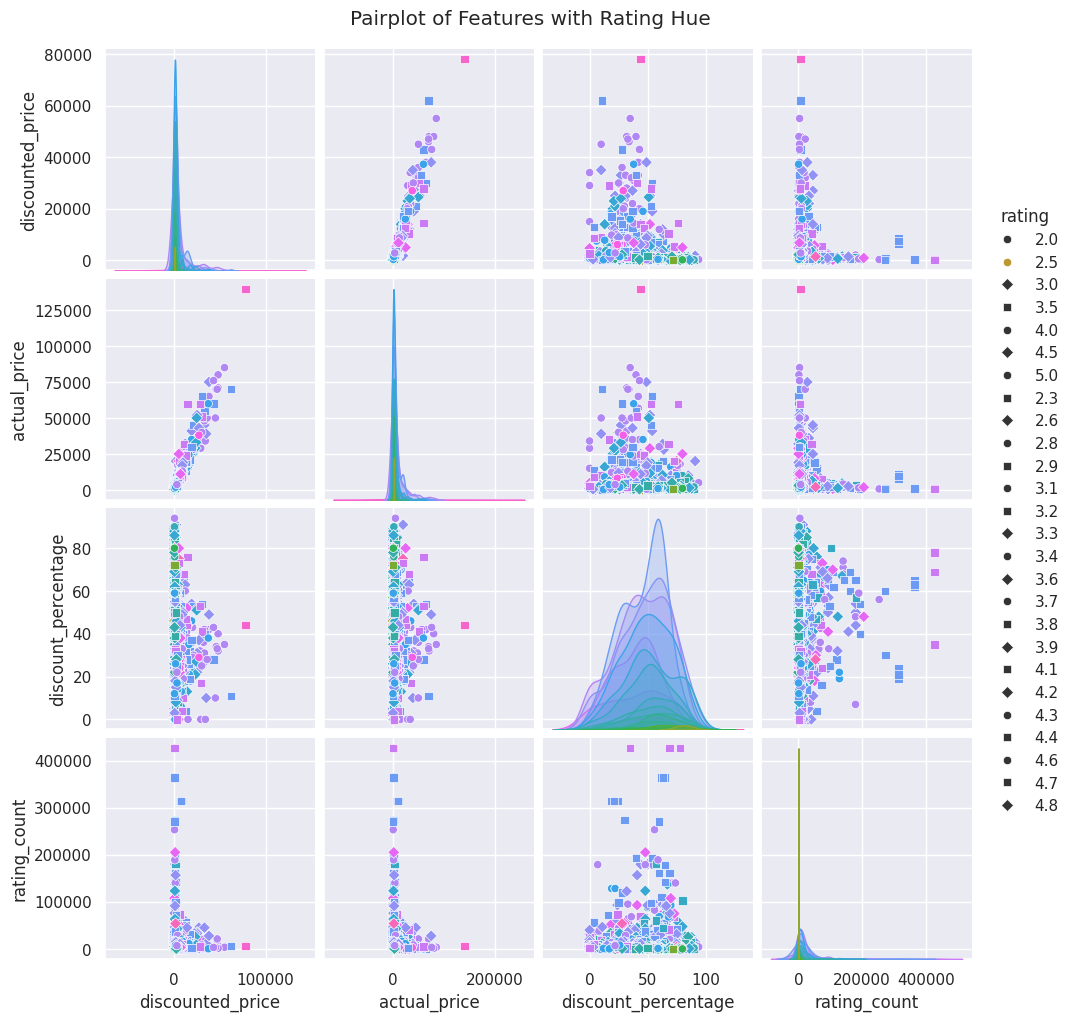

In [10]:
sns.pairplot(df_relevant, hue='rating', palette='husl', markers=["o", "s", "D"])
plt.suptitle('Pairplot of Features with Rating Hue', y=1.02)
plt.show()

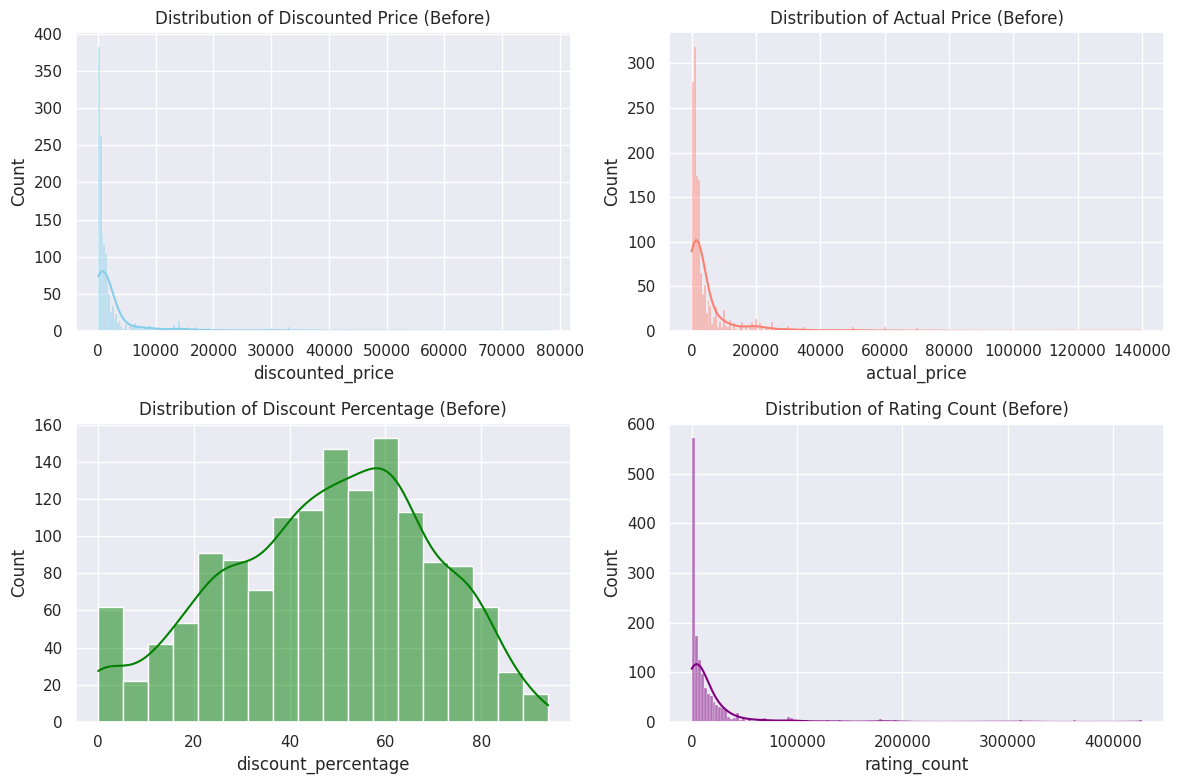

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_relevant['discounted_price'], kde=True, color='skyblue', ax=axs[0, 0])
axs[0, 0].set_title('Distribution of Discounted Price (Before)')

sns.histplot(df_relevant['actual_price'], kde=True, color='salmon', ax=axs[0, 1])
axs[0, 1].set_title('Distribution of Actual Price (Before)')

sns.histplot(df_relevant['discount_percentage'], kde=True, color='green', ax=axs[1, 0])
axs[1, 0].set_title('Distribution of Discount Percentage (Before)')

sns.histplot(df_relevant['rating_count'], kde=True, color='purple', ax=axs[1, 1])
axs[1, 1].set_title('Distribution of Rating Count (Before)')

plt.tight_layout()
plt.show()


Summary Statistics AFTER Log Transformation:
       discount_percentage       rating  discounted_price  actual_price  \
count          1464.000000  1464.000000       1464.000000   1464.000000   
mean             47.713115     4.096585          6.859032      7.606174   
std              21.627422     0.291674          1.427028      1.329914   
min               0.000000     2.000000          3.688879      3.688879   
25%              32.000000     4.000000          5.783033      6.685861   
50%              50.000000     4.100000          6.684612      7.409136   
75%              63.000000     4.300000          7.600902      8.367468   
max              94.000000     5.000000         11.264349     11.848690   

       rating_count  
count   1464.000000  
mean       8.304140  
std        2.026427  
min        1.098612  
25%        7.084645  
50%        8.552560  
75%        9.760295  
max       12.964478  


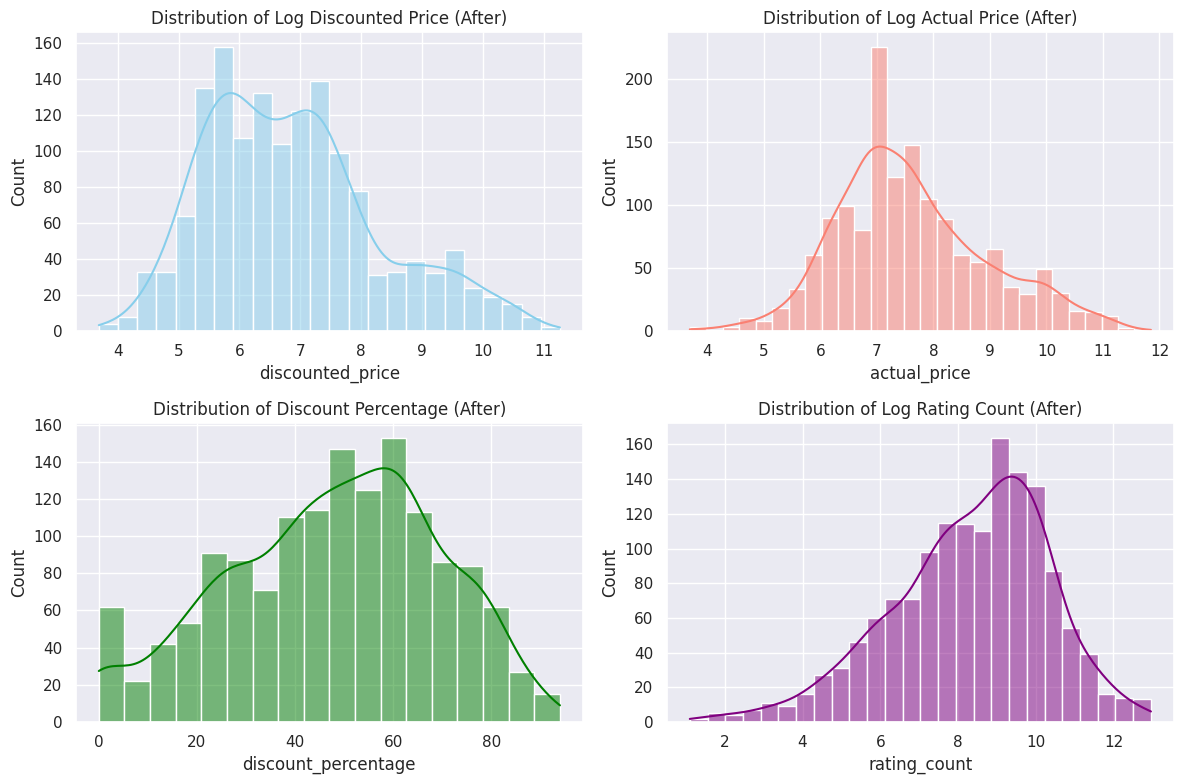

In [12]:
df_relevant['discounted_price_log'] = np.log1p(df_relevant['discounted_price'])
df_relevant['actual_price_log'] = np.log1p(df_relevant['actual_price'])
df_relevant['rating_count_log'] = np.log1p(df_relevant['rating_count'])

df_relevant = df_relevant.drop(['discounted_price', 'actual_price', 'rating_count'], axis=1)
df_relevant = df_relevant.rename(columns={
    'discounted_price_log': 'discounted_price',
    'actual_price_log': 'actual_price',
    'rating_count_log': 'rating_count'
})

print("\nSummary Statistics AFTER Log Transformation:")
print(df_relevant.describe())

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_relevant['discounted_price'], kde=True, color='skyblue', ax=axs[0, 0])
axs[0, 0].set_title('Distribution of Log Discounted Price (After)')

sns.histplot(df_relevant['actual_price'], kde=True, color='salmon', ax=axs[0, 1])
axs[0, 1].set_title('Distribution of Log Actual Price (After)')

sns.histplot(df_relevant['discount_percentage'], kde=True, color='green', ax=axs[1, 0])
axs[1, 0].set_title('Distribution of Discount Percentage (After)')

sns.histplot(df_relevant['rating_count'], kde=True, color='purple', ax=axs[1, 1])
axs[1, 1].set_title('Distribution of Log Rating Count (After)')

plt.tight_layout()
plt.show()


Boxplots BEFORE Outlier Handling:


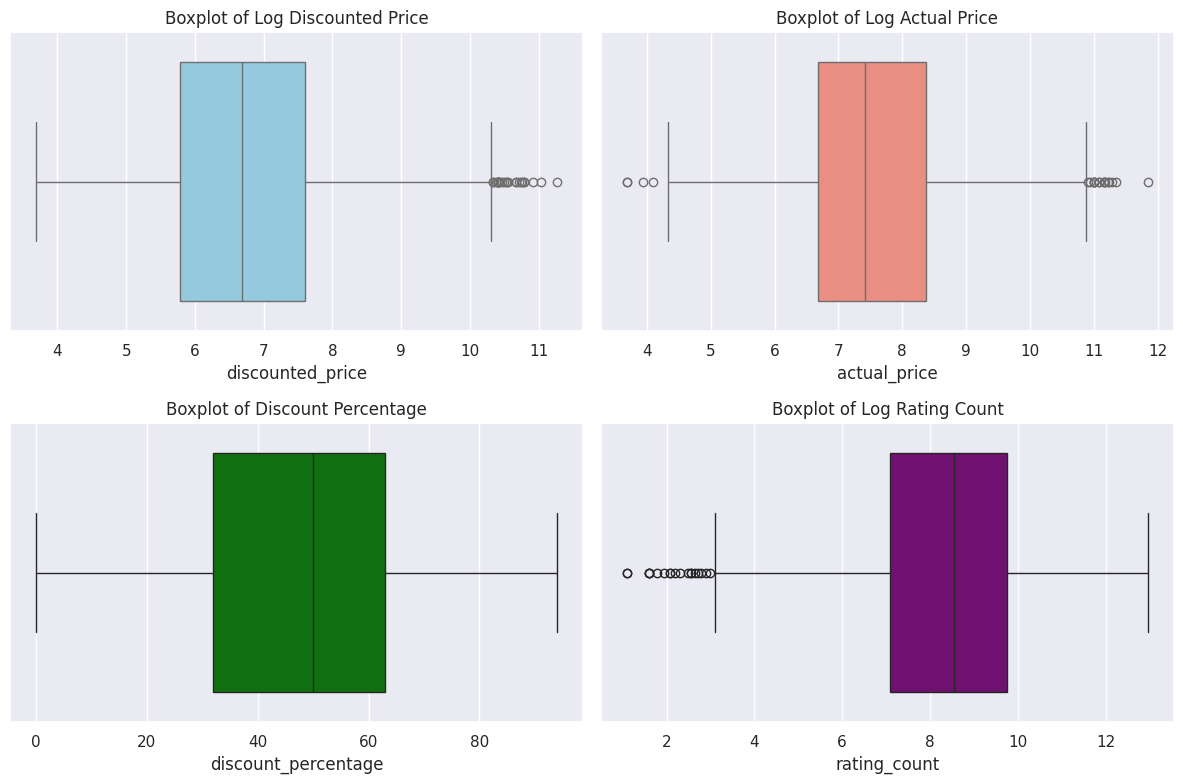

Shape AFTER Capping Outliers: (1464, 5)

Boxplots AFTER Outlier Capping:


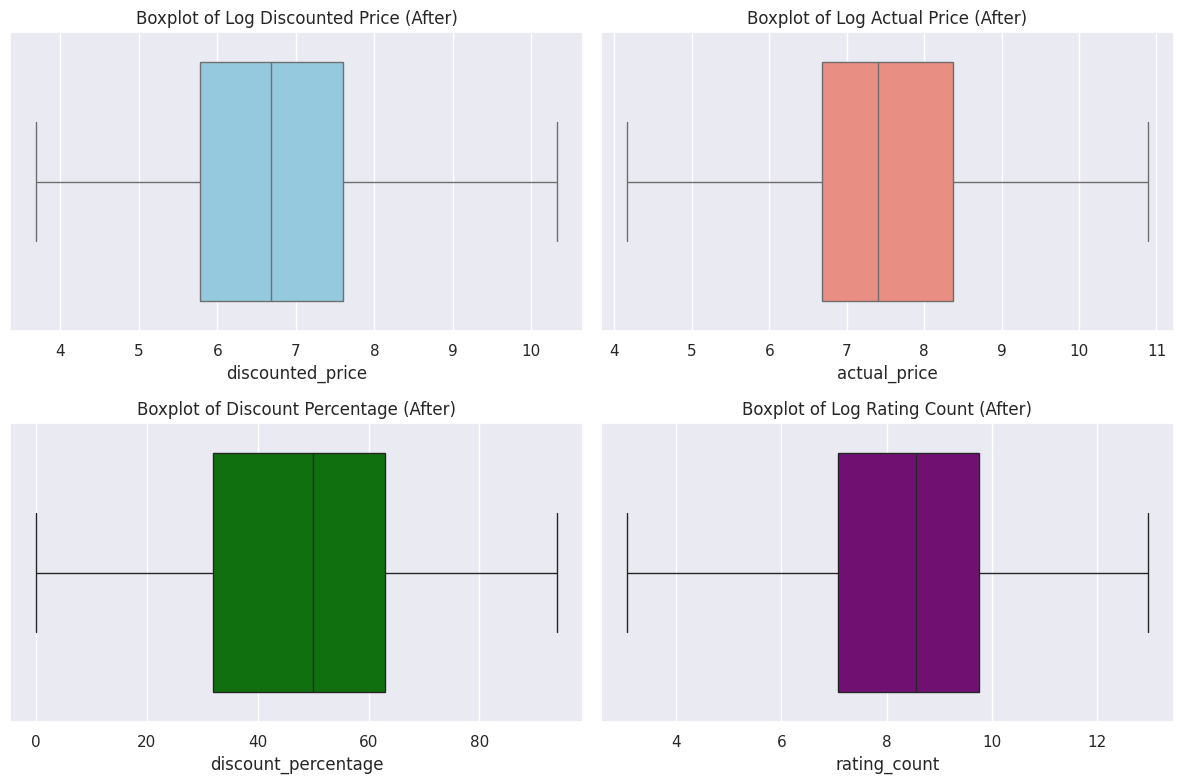

In [13]:
print("\nBoxplots BEFORE Outlier Handling:")
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x=df_relevant['discounted_price'], color='skyblue', ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Log Discounted Price')

sns.boxplot(x=df_relevant['actual_price'], color='salmon', ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Log Actual Price')

sns.boxplot(x=df_relevant['discount_percentage'], color='green', ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of Discount Percentage')

sns.boxplot(x=df_relevant['rating_count'], color='purple', ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of Log Rating Count')

plt.tight_layout()
plt.show()

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

for col in ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count']:
    df_relevant = cap_outliers(df_relevant, col)

print("Shape AFTER Capping Outliers:", df_relevant.shape)

print("\nBoxplots AFTER Outlier Capping:")
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x=df_relevant['discounted_price'], color='skyblue', ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Log Discounted Price (After)')

sns.boxplot(x=df_relevant['actual_price'], color='salmon', ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Log Actual Price (After)')

sns.boxplot(x=df_relevant['discount_percentage'], color='green', ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of Discount Percentage (After)')

sns.boxplot(x=df_relevant['rating_count'], color='purple', ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of Log Rating Count (After)')

plt.tight_layout()
plt.show()

In [14]:

df_relevant['price_ratio'] = df_relevant['discounted_price'] / df_relevant['actual_price']
df_relevant['price_diff'] = df_relevant['actual_price'] - df_relevant['discounted_price']


df_relevant.replace([np.inf, -np.inf], np.nan, inplace=True)
df_relevant = df_relevant.fillna(0)

print("NaNs after handling:", df_relevant.isna().sum().sum())
print("Infs after handling:", np.isinf(df_relevant).sum().sum())

print("\nData Head AFTER Feature Engineering:")
print(df_relevant.head())

NaNs after handling: 0
Infs after handling: 0

Data Head AFTER Feature Engineering:
   discount_percentage  rating  discounted_price  actual_price  rating_count  \
0                 64.0     4.2          5.991465      7.003065     10.096996   
1                 43.0     4.0          5.298317      5.857933     10.691831   
2                 90.0     3.9          5.298317      7.549609      8.978282   
3                 53.0     4.2          5.799093      6.551080     11.454915   
4                 61.0     4.2          5.043425      5.991465      9.735424   

   price_ratio  price_diff  
0     0.855549    1.011601  
1     0.904469    0.559616  
2     0.701800    2.251292  
3     0.885212    0.751988  
4     0.841768    0.948039  



Pairwise Relationships BEFORE Model Training:


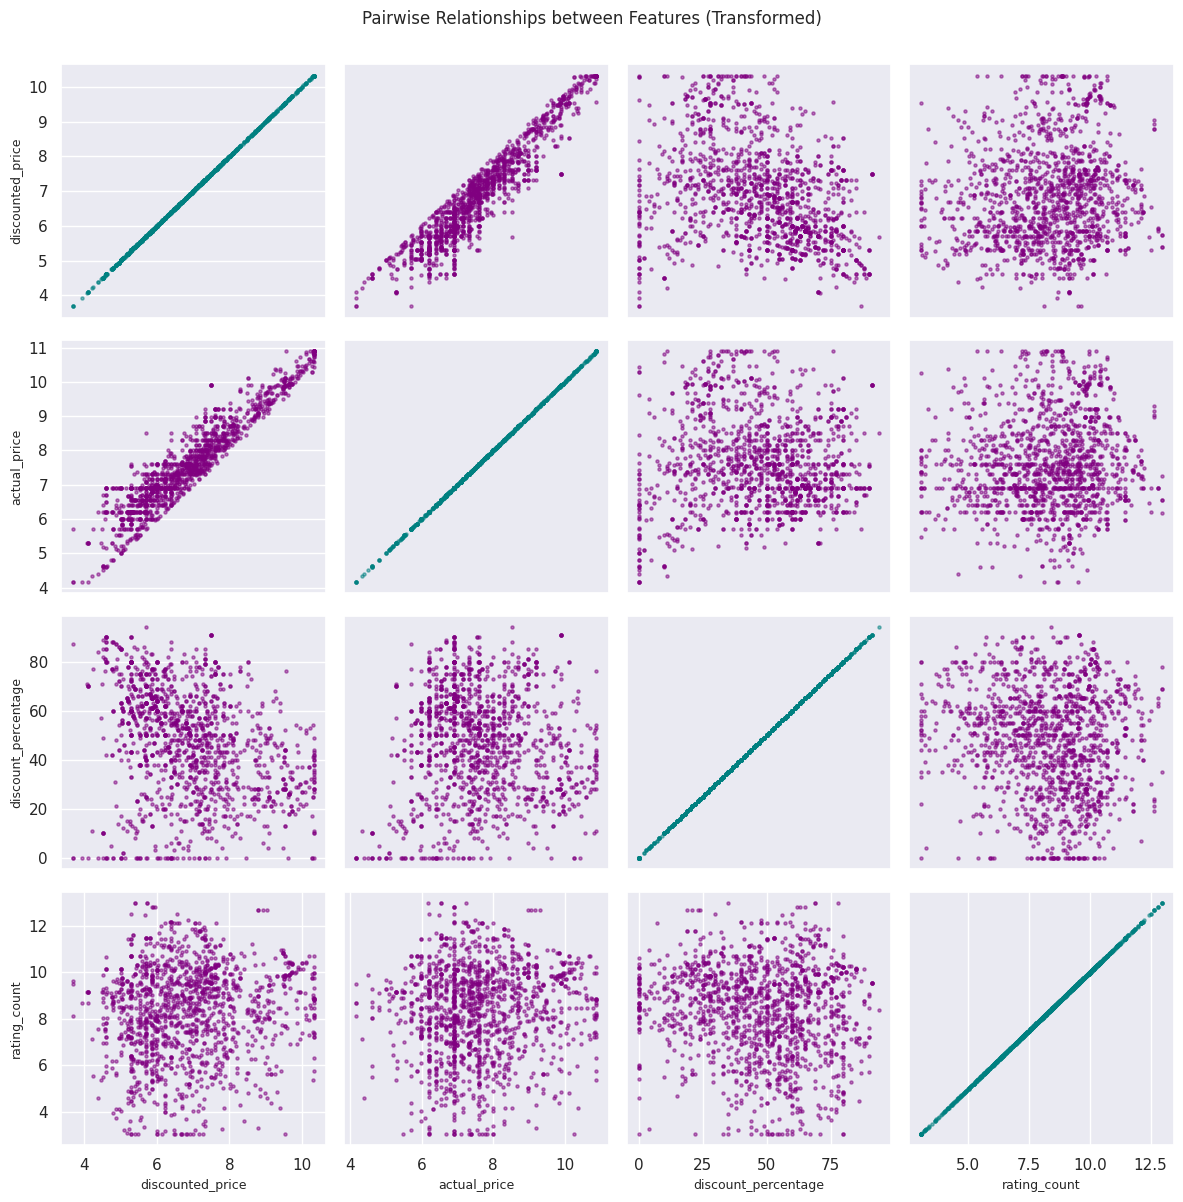

In [15]:
cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count']

print("\nPairwise Relationships BEFORE Model Training:")

fig, axs = plt.subplots(len(cols), len(cols), figsize=(12, 12))

for i in range(len(cols)):
    for j in range(len(cols)):
        axs[i, j].scatter(df_relevant[cols[j]], df_relevant[cols[i]], s=5, alpha=0.5, color='teal' if i==j else 'purple')
        axs[i, j].get_xaxis().set_visible(False)
        axs[i, j].get_yaxis().set_visible(False)

        if i == len(cols) - 1:
            axs[i, j].get_xaxis().set_visible(True)
            axs[i, j].set_xlabel(cols[j], fontsize=9)

        if j == 0:
            axs[i, j].get_yaxis().set_visible(True)
            axs[i, j].set_ylabel(cols[i], fontsize=9)

fig.suptitle('Pairwise Relationships between Features (Transformed)', fontsize=12, y=1)
plt.tight_layout()
plt.show()

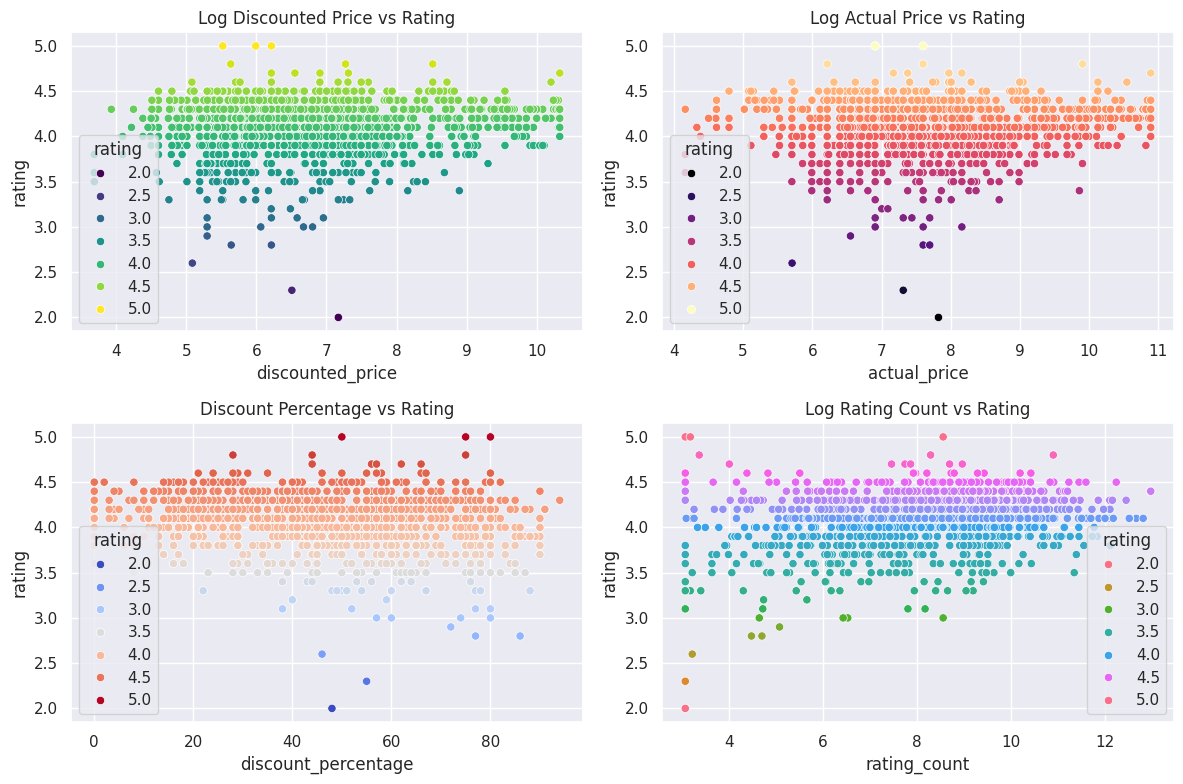

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
sns.scatterplot(x='discounted_price', y='rating', hue='rating', data=df_relevant, palette='viridis', ax=axs[0, 0])
axs[0, 0].set_title('Log Discounted Price vs Rating')

sns.scatterplot(x='actual_price', y='rating', hue='rating', data=df_relevant, palette='magma', ax=axs[0, 1])
axs[0, 1].set_title('Log Actual Price vs Rating')

sns.scatterplot(x='discount_percentage', y='rating', hue='rating', data=df_relevant, palette='coolwarm', ax=axs[1, 0])
axs[1, 0].set_title('Discount Percentage vs Rating')

sns.scatterplot(x='rating_count', y='rating', hue='rating', data=df_relevant, palette='husl', ax=axs[1, 1])
axs[1, 1].set_title('Log Rating Count vs Rating')

plt.tight_layout()
plt.show()

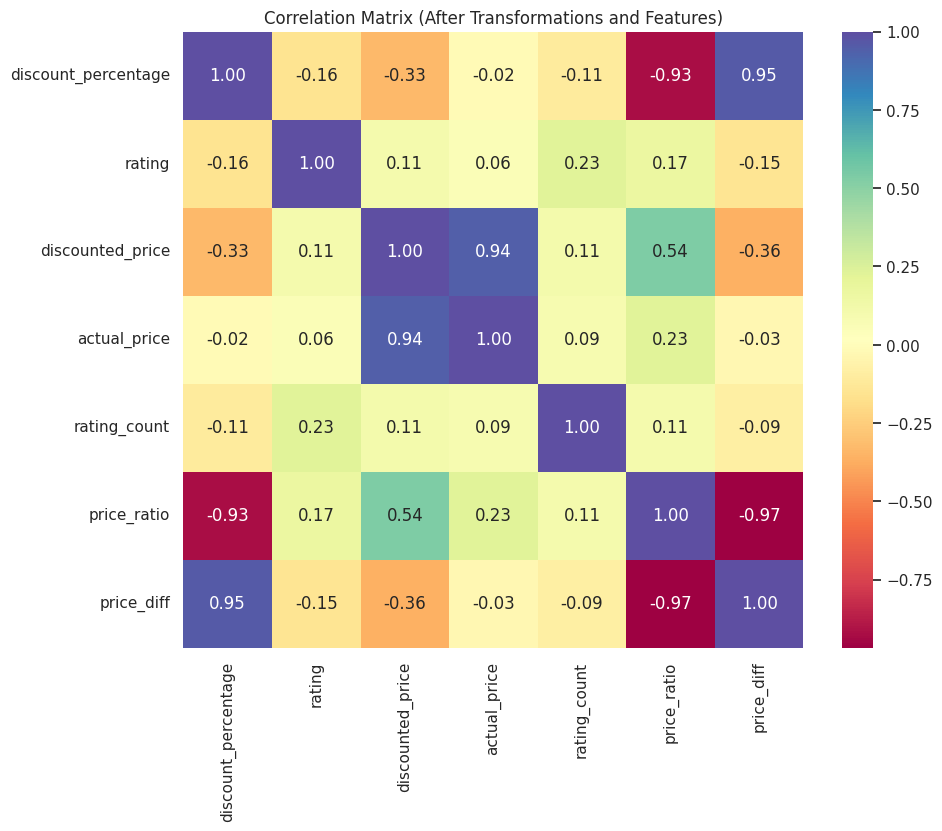

In [17]:
plt.figure(figsize=(10, 8))
corr = df_relevant.corr()
sns.heatmap(corr, annot=True, cmap='Spectral', fmt='.2f')
plt.title('Correlation Matrix (After Transformations and Features)')
plt.show()

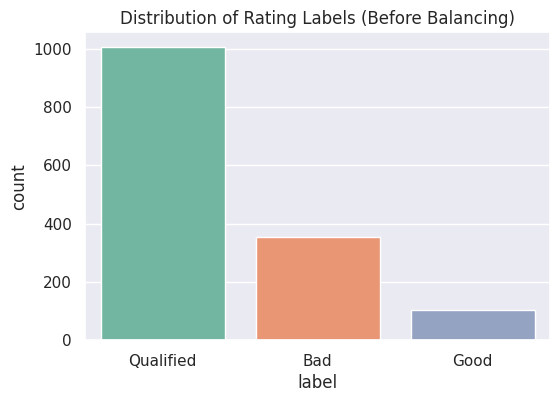

In [18]:

def classify_rating(rating):
    if rating >= 4.5:
        return 'Good'
    elif rating >= 4.0:
        return 'Qualified'
    else:
        return 'Bad'

df_relevant['label'] = df_relevant['rating'].apply(classify_rating)

label_map = {'Bad': 0, 'Qualified': 1, 'Good': 2}
df_relevant['label_code'] = df_relevant['label'].map(label_map)

plt.figure(figsize=(6, 4))
sns.countplot(x='label', hue='label', data=df_relevant, palette='Set2', legend=False)
plt.title('Distribution of Rating Labels (Before Balancing)')
plt.show()

In [19]:
X_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count', 'price_ratio', 'price_diff']
X = df_relevant[X_cols]
y = df_relevant['label_code']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [20]:
# Parameter grid for RandomForest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Train RandomForest without scaling
clf_rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(clf_rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Best model and evaluation
best_clf_rf = grid_search_rf.best_estimator_
y_pred_rf = best_clf_rf.predict(X_test)

print("Best Parameters (Unscaled RF):", grid_search_rf.best_params_)
print("Best Score (Unscaled RF):", grid_search_rf.best_score_)
print("Accuracy (RF):", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Best Parameters (Unscaled RF): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Score (Unscaled RF): 0.7148684839789574
Accuracy (RF): 0.7181818181818181
              precision    recall  f1-score   support

           0       0.58      0.43      0.49       107
           1       0.75      0.89      0.82       302
           2       0.00      0.00      0.00        31

    accuracy                           0.72       440
   macro avg       0.45      0.44      0.44       440
weighted avg       0.66      0.72      0.68       440



In [21]:
# Scale the data and retrain RandomForest
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_rf_scaled = RandomForestClassifier(random_state=42)
grid_search_rf_scaled = GridSearchCV(clf_rf_scaled, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf_scaled.fit(X_train_scaled, y_train)

# Best scaled model and evaluation
best_clf_rf_scaled = grid_search_rf_scaled.best_estimator_
y_pred_rf_scaled = best_clf_rf_scaled.predict(X_test_scaled)

print("Best Parameters (Scaled RF):", grid_search_rf_scaled.best_params_)
print("Best Score (Scaled RF):", grid_search_rf_scaled.best_score_)
print("Accuracy (Scaled RF):", accuracy_score(y_test, y_pred_rf_scaled))
print(classification_report(y_test, y_pred_rf_scaled))

Best Parameters (Scaled RF): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Score (Scaled RF): 0.7138880918220947
Accuracy (Scaled RF): 0.7181818181818181
              precision    recall  f1-score   support

           0       0.59      0.43      0.50       107
           1       0.75      0.89      0.82       302
           2       0.00      0.00      0.00        31

    accuracy                           0.72       440
   macro avg       0.45      0.44      0.44       440
weighted avg       0.66      0.72      0.68       440



In [22]:
# Parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

# Train XGBoost without scaling
clf_xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
grid_search_xgb = GridSearchCV(clf_xgb, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

# Best model and evaluation
best_clf_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_clf_xgb.predict(X_test)

print("Best Parameters (Unscaled XGB):", grid_search_xgb.best_params_)
print("Best Score (Unscaled XGB):", grid_search_xgb.best_score_)
print("Accuracy (XGB):", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Best Parameters (Unscaled XGB): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best Score (Unscaled XGB): 0.7109660449545672
Accuracy (XGB): 0.6931818181818182
              precision    recall  f1-score   support

           0       0.48      0.40      0.44       107
           1       0.75      0.86      0.80       302
           2       0.40      0.06      0.11        31

    accuracy                           0.69       440
   macro avg       0.54      0.44      0.45       440
weighted avg       0.66      0.69      0.67       440



In [23]:
# Train XGBoost with scaled data
clf_xgb_scaled = XGBClassifier(random_state=42, eval_metric='mlogloss')
grid_search_xgb_scaled = GridSearchCV(clf_xgb_scaled, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_xgb_scaled.fit(X_train_scaled, y_train)

# Best scaled model and evaluation
best_clf_xgb_scaled = grid_search_xgb_scaled.best_estimator_
y_pred_xgb_scaled = best_clf_xgb_scaled.predict(X_test_scaled)

print("Best Parameters (Scaled XGB):", grid_search_xgb_scaled.best_params_)
print("Best Score (Scaled XGB):", grid_search_xgb_scaled.best_score_)
print("Accuracy (Scaled XGB):", accuracy_score(y_test, y_pred_xgb_scaled))
print(classification_report(y_test, y_pred_xgb_scaled))

Best Parameters (Scaled XGB): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best Score (Scaled XGB): 0.7109660449545672
Accuracy (Scaled XGB): 0.6931818181818182
              precision    recall  f1-score   support

           0       0.48      0.40      0.44       107
           1       0.75      0.86      0.80       302
           2       0.40      0.06      0.11        31

    accuracy                           0.69       440
   macro avg       0.54      0.44      0.45       440
weighted avg       0.66      0.69      0.67       440



In [24]:
# Parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Train KNN without scaling
clf_knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(clf_knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

# Best model and evaluation
best_clf_knn = grid_search_knn.best_estimator_
y_pred_knn = best_clf_knn.predict(X_test)

print("Best Parameters (Unscaled KNN):", grid_search_knn.best_params_)
print("Best Score (Unscaled KNN):", grid_search_knn.best_score_)
print("Accuracy (KNN):", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Best Parameters (Unscaled KNN): {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best Score (Unscaled KNN): 0.7158249641319943
Accuracy (KNN): 0.6863636363636364
              precision    recall  f1-score   support

           0       0.47      0.36      0.41       107
           1       0.74      0.87      0.80       302
           2       0.17      0.03      0.05        31

    accuracy                           0.69       440
   macro avg       0.46      0.42      0.42       440
weighted avg       0.64      0.69      0.65       440



In [25]:
# Train KNN with scaled data
clf_knn_scaled = KNeighborsClassifier()
grid_search_knn_scaled = GridSearchCV(clf_knn_scaled, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_knn_scaled.fit(X_train_scaled, y_train)

# Best scaled model and evaluation
best_clf_knn_scaled = grid_search_knn_scaled.best_estimator_
y_pred_knn_scaled = best_clf_knn_scaled.predict(X_test_scaled)

print("Best Parameters (Scaled KNN):", grid_search_knn_scaled.best_params_)
print("Best Score (Scaled KNN):", grid_search_knn_scaled.best_score_)
print("Accuracy (Scaled KNN):", accuracy_score(y_test, y_pred_knn_scaled))
print(classification_report(y_test, y_pred_knn_scaled))

Best Parameters (Scaled KNN): {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best Score (Scaled KNN): 0.7187757054041128
Accuracy (Scaled KNN): 0.6795454545454546
              precision    recall  f1-score   support

           0       0.49      0.47      0.48       107
           1       0.76      0.82      0.79       302
           2       0.00      0.00      0.00        31

    accuracy                           0.68       440
   macro avg       0.42      0.43      0.42       440
weighted avg       0.64      0.68      0.66       440



Explained variance ratio: [0.9843142  0.00858287]
Cumulative explained variance: [0.9843142  0.99289708]


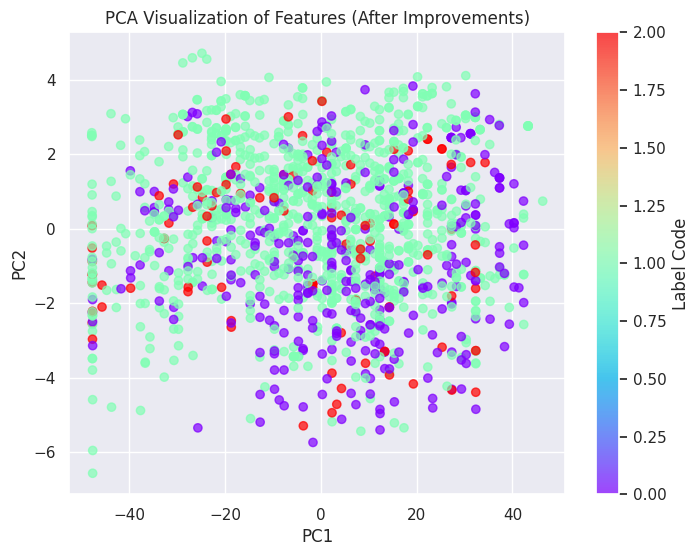

In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='rainbow', alpha=0.7)
plt.colorbar(scatter, label='Label Code')
plt.title('PCA Visualization of Features (After Improvements)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [27]:

os.makedirs('/content/drive/MyDrive/DataWH/output', exist_ok=True)
df_relevant.to_csv('/content/drive/MyDrive/DataWH/output/amazon_processed.csv', index=False)